In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 13,
        "axes.titlesize": 14,
        "figure.titlesize": 16,
        "figure.dpi": 150,
    }
)

# Пути к файлам данных Этапа 1 и Этапа 2
CSV_STAGE1 = "results_stage150.csv"  # Данные read/lseek
CSV_STAGE2 = "results_stage2.csv"  # Данные mmap
CONFIDENCE_LEVEL = 0.95

# Загрузка
df1_raw = pd.read_csv(CSV_STAGE1)
df2_raw = pd.read_csv(CSV_STAGE2)

# Фильтрация прогревочных прогонов (warmup)
df1 = df1_raw[df1_raw["run_type"] == "test"].copy()
df1["method"] = "read/lseek"

df2 = df2_raw[df2_raw["run_type"] == "test"].copy()
df2["method"] = "mmap"

# Объединение датафреймов
df_all = pd.concat([df1, df2], ignore_index=True)

# Приведение типов и очистка числовых полей
target_cols = [
    "wall_s",
    "user_s",
    "sys_s",
    "cpu_pct",
    "vol_ctx",
    "invol_ctx",
    "maj_flt",
    "min_flt",
    "max_rss_kb",
]
for col in target_cols:
    if col in df_all.columns:
        if col == "cpu_pct":
            df_all[col] = (
                df_all[col]
                .astype(str)
                .str.replace("%", "", regex=False)
                .str.strip()
            )
        df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

print(f"Всего зачётных измерений: {len(df_all)}")
print(df_all.groupby(["method", "mode"]).size())

Всего зачётных измерений: 380
method      mode   
mmap        cache       40
            nocache     40
read/lseek  cache      150
            nocache    150
dtype: int64


In [25]:
def compute_stats(group, target_col="wall_s", conf=CONFIDENCE_LEVEL):
    data = group[target_col].dropna().to_numpy()
    n = len(data)
    mean = np.mean(data)
    std = np.std(data, ddof=1)
    sem = std / np.sqrt(n)

    t_crit = stats.t.ppf((1 + conf) / 2.0, df=n - 1)
    margin = t_crit * sem
    rel_error = (margin / mean) * 100 if mean != 0 else 0

    return pd.Series(
        {
            "N": int(n),
            "Mean [s]": mean,
            "Std [s]": std,
            "SEM [s]": sem,
            "CI_Margin [s]": margin,
            "CI_Lower [s]": mean - margin,
            "CI_Upper [s]": mean + margin,
            "Rel_Error [%]": rel_error,
            "Min [s]": np.min(data),
            "Max [s]": np.max(data),
        }
    )


summary_stats = df_all.groupby(["method", "mode"]).apply(
    compute_stats, include_groups=False
)

print("=== СВОДНАЯ СТАТИСТИКА ВРЕМЕНИ ВЫПОЛНЕНИЯ (WALL CLOCK TIME) ===")
display(
    summary_stats.style.format(
        {
            "Mean [s]": "{:.5f}",
            "Std [s]": "{:.5f}",
            "SEM [s]": "{:.6f}",
            "CI_Margin [s]": "{:.5f}",
            "CI_Lower [s]": "{:.5f}",
            "CI_Upper [s]": "{:.5f}",
            "Rel_Error [%]": "{:.2f}%",
            "Min [s]": "{:.5f}",
            "Max [s]": "{:.5f}",
        }
    )
)

=== СВОДНАЯ СТАТИСТИКА ВРЕМЕНИ ВЫПОЛНЕНИЯ (WALL CLOCK TIME) ===


/tmp/nix-shell.51y3zv/ipykernel_1243982/713300364.py:13: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.barplot(
/tmp/nix-shell.51y3zv/ipykernel_1243982/713300364.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


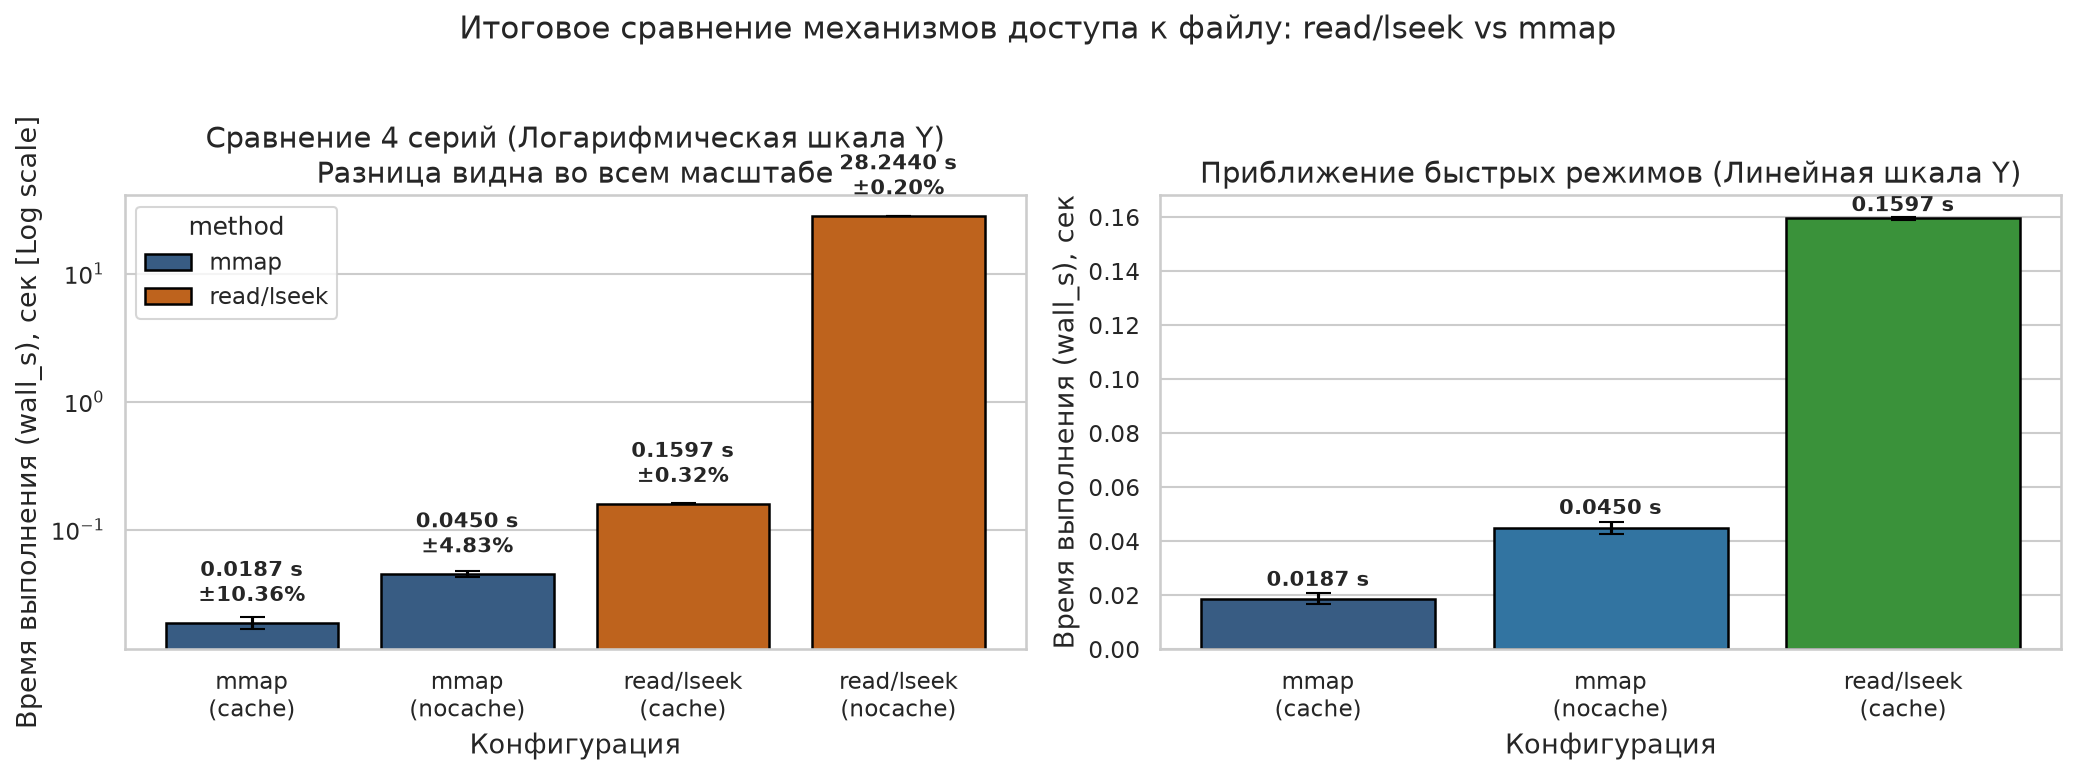

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Подготовка данных
summary_df = summary_stats.reset_index()
summary_df["label"] = summary_df["method"] + "\n(" + summary_df["mode"] + ")"

palette = {
    "read/lseek": "#2b5c8f",
    "mmap": "#2ca02c",
}

# 1. Логарифмическая шкала (позволяет увидеть все 4 конфигурации)
sns.barplot(
    data=summary_df,
    x="label",
    y="Mean [s]",
    hue="method",
    dodge=False,
    ax=axes[0],
    palette=["#2b5c8f", "#d95f02", "#1f77b4", "#2ca02c"],
    edgecolor="black",
    linewidth=1.2,
)

# Добавляем усы погрешности вручную
for idx, row in summary_df.iterrows():
    axes[0].errorbar(
        x=idx,
        y=row["Mean [s]"],
        yerr=row["CI_Margin [s]"],
        fmt="none",
        c="black",
        capsize=6,
        lw=1.5,
    )
    axes[0].text(
        idx,
        row["Mean [s]"] * 1.3,
        f"{row['Mean [s]']:.4f} s\n±{row['Rel_Error [%]']:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

axes[0].set_yscale("log")
axes[0].set_title(
    "Сравнение 4 серий (Логарифмическая шкала Y)\nРазница видна во всем масштабе"
)
axes[0].set_ylabel("Время выполнения (wall_s), сек [Log scale]")
axes[0].set_xlabel("Конфигурация")

# 2. Детальный зум на быстрые конфигурации (без блокирующего I/O read no-cache)
fast_subset = summary_df[summary_df["label"] != "read/lseek\n(nocache)"]
sns.barplot(
    data=fast_subset,
    x="label",
    y="Mean [s]",
    ax=axes[1],
    palette=["#2b5c8f", "#1f77b4", "#2ca02c"],
    edgecolor="black",
    linewidth=1.2,
)

for idx, (_, row) in enumerate(fast_subset.iterrows()):
    axes[1].errorbar(
        x=idx,
        y=row["Mean [s]"],
        yerr=row["CI_Margin [s]"],
        fmt="none",
        c="black",
        capsize=6,
        lw=1.5,
    )
    axes[1].text(
        idx,
        row["Mean [s]"] + row["CI_Margin [s]"] * 1.5,
        f"{row['Mean [s]']:.4f} s",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
    )

axes[1].set_title("Приближение быстрых режимов (Линейная шкала Y)")
axes[1].set_ylabel("Время выполнения (wall_s), сек")
axes[1].set_xlabel("Конфигурация")

plt.suptitle(
    "Итоговое сравнение механизмов доступа к файлу: read/lseek vs mmap",
    fontsize=15,
    y=1.03,
)
plt.tight_layout()
plt.savefig("stage3_final_time_comparison.png", bbox_inches="tight")
plt.show()

=== СИСТЕМНЫЕ МЕТРИКИ ОС (СРЕДНИЕ ЗНАЧЕНИЯ) ===


/tmp/nix-shell.51y3zv/ipykernel_1243982/1338238208.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/nix-shell.51y3zv/ipykernel_1243982/1338238208.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


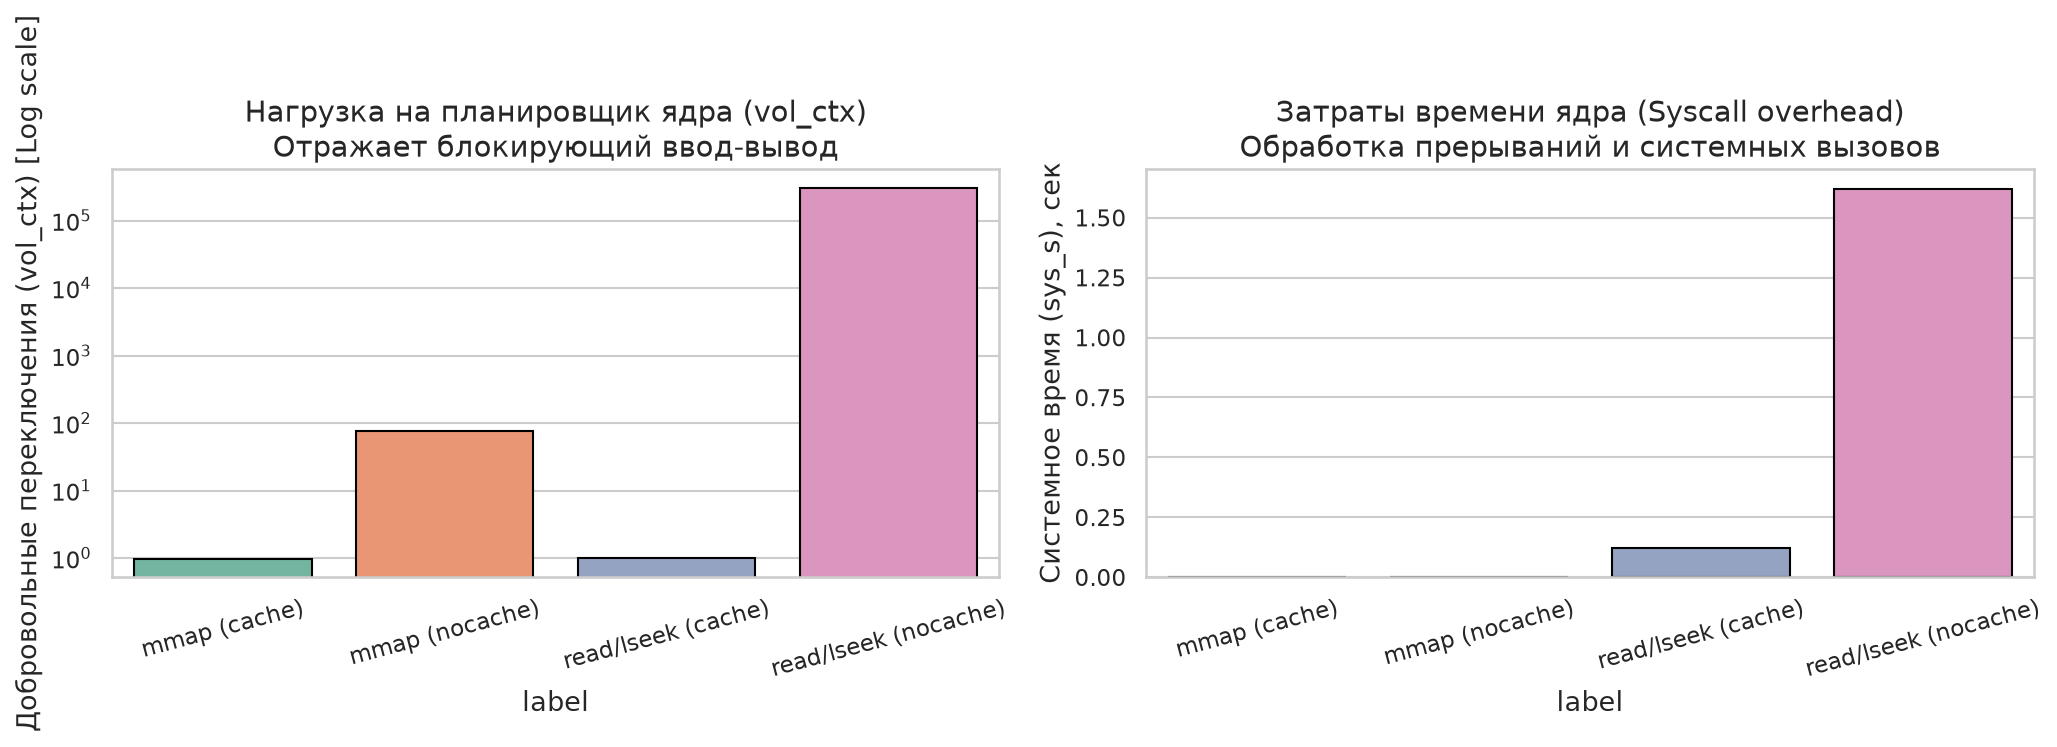

In [27]:
# Агрегируем метрики ОС
os_summary = df_all.groupby(["method", "mode"])[
    ["sys_s", "user_s", "vol_ctx", "invol_ctx", "min_flt", "maj_flt", "cpu_pct"]
].mean()

print("=== СИСТЕМНЫЕ МЕТРИКИ ОС (СРЕДНИЕ ЗНАЧЕНИЯ) ===")
display(
    os_summary.style.format(
        {
            "sys_s": "{:.4f} s",
            "user_s": "{:.4f} s",
            "vol_ctx": "{:,.0f}",
            "invol_ctx": "{:.1f}",
            "min_flt": "{:,.0f}",
            "maj_flt": "{:.1f}",
            "cpu_pct": "{:.1f}%",
        }
    )
)

# Построение графиков переключений контекста и времени ядра
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

os_plot_df = os_summary.reset_index()
os_plot_df["label"] = os_plot_df["method"] + " (" + os_plot_df["mode"] + ")"

# 1. Переключения контекста (Voluntary Context Switches)
sns.barplot(
    data=os_plot_df,
    x="label",
    y="vol_ctx",
    ax=axes[0],
    palette="Set2",
    edgecolor="black",
)
axes[0].set_yscale("log")
axes[0].set_ylabel("Добровольные переключения (vol_ctx) [Log scale]")
axes[0].set_title(
    "Нагрузка на планировщик ядра (vol_ctx)\nОтражает блокирующий ввод-вывод"
)
axes[0].tick_params(axis="x", rotation=15)

# 2. Системное время процессора (Kernel Sys Time)
sns.barplot(
    data=os_plot_df,
    x="label",
    y="sys_s",
    ax=axes[1],
    palette="Set2",
    edgecolor="black",
)
axes[1].set_ylabel("Системное время (sys_s), сек")
axes[1].set_title(
    "Затраты времени ядра (Syscall overhead)\nОбработка прерываний и системных вызовов"
)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig("stage3_system_metrics.png", bbox_inches="tight")
plt.show()